# 08 — Causal-ML: isolate the shear effect (DML + causal forest)
**Kernel: `Python (pf_ml)`.** 0–6 km shear as a continuous *treatment*, confounders (CAPE, CIN, moisture, skin-temp, |lat|) partialled out by ML nuisance models. `LinearDML` → debiased average partial effect + CI; `CausalForestDML(X=CAPE)` → heterogeneous effect (does shear matter more at high/low CAPE?). **Associational under unconfoundedness.**

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, warnings; warnings.filterwarnings('ignore')
from functools import reduce
from _shc import *
con = connect()
# Predictors: ambient CAPE + CIN + moisture + SKIN TEMP (skt; defined over land&ocean,
# unlike SST) + 3 shear layers + |lat|.  Treatment = 0-6 km shear.
PREDICTORS = [AMBIENT_CAPE, CIN, MOISTURE, 'mean_skt_2p50deg',
              'shear_1000m_centroid','shear_3000m_centroid','shear_6000m_centroid','abs_lat']
TREATMENT  = SHEAR
RESPONSES  = ['ht40_km','ht30_km','ht20_km','min_pct_85_89','min_pct_37']
# max_ht_40dbz is NULL when no 40-dBZ echo exists -> for echo-top HEIGHT models we sample the
# deep subset (finite ht40); CIN is occasionally NULL -> impute 0 (no inhibition).

CTRL = [AMBIENT_CAPE, CIN, MOISTURE, 'mean_skt_2p50deg', 'abs_lat']
df = load_sample(con, ['ht40_km', TREATMENT]+CTRL, mission='TRMM', n=200_000, where='AND ht40_km IS NOT NULL')
df[CIN] = df[CIN].fillna(0.0); df = df.dropna(subset=[TREATMENT,'ht40_km']+CTRL)
Y = df['ht40_km'].to_numpy(); T = df[TREATMENT].to_numpy()
W = df[CTRL].to_numpy(); Xhet = df[[AMBIENT_CAPE]].to_numpy()
print('sample:', df.shape)

sample: (200000, 7)


### LinearDML — debiased average partial effect of shear (km per m/s)

In [2]:
from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor as GBR
est = LinearDML(model_y=GBR(n_estimators=150), model_t=GBR(n_estimators=150), random_state=0)
est.fit(Y, T, X=None, W=W)
ate = est.ate(X=None); lo,hi = est.ate_interval(X=None, alpha=0.05)
print(f'ATE of 0-6 km shear on 40-dBZ top = {ate:+.4f} km per (m/s)  [95% CI {lo:+.4f}, {hi:+.4f}]')
print('(positive ⇒ supports H1 once CAPE & co. are held; compare to raw corr which is negative)')

ATE of 0-6 km shear on 40-dBZ top = -0.0118 km per (m/s)  [95% CI -0.0128, -0.0107]
(positive ⇒ supports H1 once CAPE & co. are held; compare to raw corr which is negative)


### CausalForestDML — heterogeneity of the shear effect in CAPE

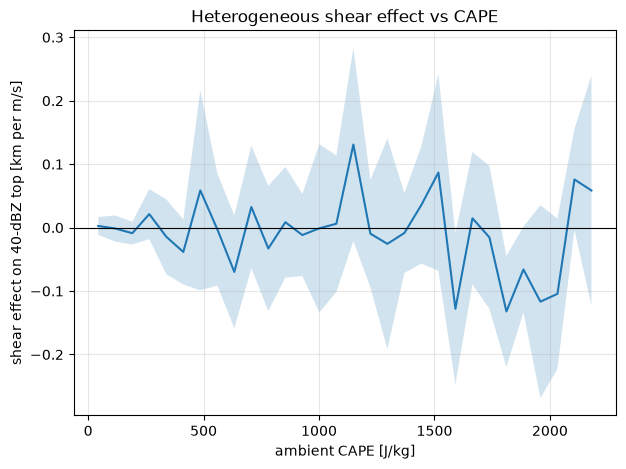

In [3]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor as GBR
cf = CausalForestDML(model_y=GBR(n_estimators=120), model_t=GBR(n_estimators=120),
                     n_estimators=800, random_state=0).fit(Y, T, X=Xhet, W=W)
grid = np.linspace(np.percentile(Xhet,5), np.percentile(Xhet,95), 30).reshape(-1,1)
eff = cf.effect(grid); lo,hi = cf.effect_interval(grid, alpha=0.05)
plt.figure(figsize=(7,5)); plt.plot(grid, eff); plt.fill_between(grid[:,0], lo, hi, alpha=.2)
plt.axhline(0,color='k',lw=.8); plt.xlabel('ambient CAPE [J/kg]')
plt.ylabel('shear effect on 40-dBZ top [km per m/s]')
plt.title('Heterogeneous shear effect vs CAPE'); plt.grid(alpha=.3); plt.show()